In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import anndata

In [3]:
RESULTS_ROOT = Path("../fairness_results")
LIB_SIZE_CSV = Path("client_library_sizes.csv")  

RUNS = {
    "FedAvg (baseline, q=0)": dict(run_tag="qffl_q0p0", strategy_name="qffl", q=0.0),
    "Uniform weighting":      dict(run_tag="uniform",   strategy_name="uniform", q=None),
    "q-FFL (q=0.5)":       dict(run_tag="qffl_q0p5", strategy_name="qffl", q=0.5),
    "q-FFL (q=1)":         dict(run_tag="qffl_q1p0", strategy_name="qffl", q=1.0),
    "q-FFL (q=2)":            dict(run_tag="qffl_q2p0", strategy_name="qffl", q=2.0),
    "q-FFL (q=5)":            dict(run_tag="qffl_q5p0", strategy_name="qffl", q=5.0),
    "Adaptive q-FFL":      dict(run_tag="adaptive_qffl", strategy_name="adaptive_qffl", q=1.0),
}

In [4]:
def jain_index(values) -> float:
    v = np.array(values, dtype=float)
    sq_sum = (v ** 2).sum()
    return float((v.sum() ** 2) / (len(v) * sq_sum)) if sq_sum > 0 else 1.0


def load_run(cfg: dict):
    log_dir = RESULTS_ROOT / f"model_federated_{cfg['run_tag']}"
    csv_path = log_dir / f"fairness_log.csv"
    jsonl_path = log_dir / f"fairness_metrics.jsonl"

    df = pd.read_csv(csv_path)

    records = []
    with open(jsonl_path) as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    metrics_df = pd.DataFrame(records)

    df = df.merge(lib_df[["client_id", "mean_lib_size"]], on="client_id", how="left")
    df["normalized_loss"] = df["valid_loss"] / df["mean_lib_size"]
    return df, metrics_df


def normalized_metrics_over_rounds(df: pd.DataFrame) -> pd.DataFrame:
    """Per-round Jain's index etc. computed on normalized_loss -- the jsonl
    logs only ever stored the raw-loss version, so this is recomputed here."""
    rows = []
    for r, g in df.groupby("round"):
        rows.append({
            "round": r,
            "jain_index_norm": jain_index(g["normalized_loss"]),
            "mean_norm_loss": g["normalized_loss"].mean(),
            "worst_norm_loss": g["normalized_loss"].max(),
            "best_norm_loss": g["normalized_loss"].min(),
        })
    return pd.DataFrame(rows).sort_values("round")

In [5]:
lib_df = pd.read_csv(LIB_SIZE_CSV)
lib_df

,client_id,n_cells,mean_lib_size,median_lib_size
0,0,201,10268.771484,10022.187500
1,1,128,10961.942383,10981.234375
2,2,387,7506.309570,7502.605469
3,3,345,7187.620117,7230.340820
4,4,721,7196.999512,7199.510742
5,5,261,8246.619141,8177.386230
6,6,298,10910.443359,11073.988281


In [6]:
runs = {label: load_run(cfg) for label, cfg in RUNS.items()}
print(f"Loaded {len(runs)} runs: {list(runs.keys())}")

Loaded 7 runs: ['FedAvg (baseline, q=0)', 'Uniform weighting', 'q-FFL (q=0.5)', 'q-FFL (q=1)', 'q-FFL (q=2)', 'q-FFL (q=5)', 'Adaptive q-FFL']


In [ ]:
rows = []
for label, (df, metrics_df) in runs.items():
    final_round = df["round"].max()
    final_df = df[df["round"] == final_round]

    global_weighted_raw = np.average(final_df["valid_loss"], weights=final_df["num_examples"])
    global_weighted_norm = np.average(final_df["normalized_loss"], weights=final_df["num_examples"])

    final_metrics_raw = metrics_df[metrics_df["round"] == metrics_df["round"].max()].iloc[0]
    jain_norm_final = jain_index(final_df["normalized_loss"])

    r_lib, p_lib = pearsonr(final_df["mean_lib_size"], final_df["valid_loss"])
    r_norm, p_norm = pearsonr(final_df["num_examples"], final_df["normalized_loss"])

    rows.append({
        "strategy": label,
        "q": RUNS[label].get("q"),
        "global_weighted_raw_loss": global_weighted_raw,
        "global_weighted_norm_loss": global_weighted_norm,
        "jain_raw": final_metrics_raw["jain_index"],
        "jain_norm": jain_norm_final,
        "worst_client_raw": final_metrics_raw["worst_client_loss"],
        "best_client_raw": final_metrics_raw["best_client_loss"],
        "worst_client_norm": final_df["normalized_loss"].max(),
        "best_client_norm": final_df["normalized_loss"].min(),
        "corr_libsize_vs_rawloss_r": r_lib,
        "corr_libsize_vs_rawloss_p": p_lib,
        "corr_clientsize_vs_normloss_r": r_norm,
        "corr_clientsize_vs_normloss_p": p_norm,
    })

summary_df = pd.DataFrame(rows).set_index("strategy")
summary_df.round(3)

,q,global_weighted_raw_loss,global_weighted_norm_loss,jain_raw,jain_norm,worst_client_raw,best_client_raw,worst_client_norm,best_client_norm,corr_libsize_vs_rawloss_r,corr_libsize_vs_rawloss_p,corr_clientsize_vs_normloss_r,corr_clientsize_vs_normloss_p
strategy,,,,,,,,,,,,,
"FedAvg (baseline, q=0)",0.0,1215.220,0.130,0.500,0.575,5376.450,533.151,0.490,0.074,0.814,0.026,-0.534,0.217
Uniform weighting,NaN,1193.901,0.129,0.517,0.598,5052.295,545.184,0.461,0.076,0.814,0.026,-0.523,0.228
q-FFL (q=0.5),0.5,1194.995,0.129,0.510,0.590,5188.258,550.909,0.473,0.077,0.810,0.027,-0.533,0.218
q-FFL (q=1),1.0,1197.270,0.130,0.532,0.618,4953.146,583.217,0.452,0.081,0.812,0.027,-0.529,0.222
q-FFL (q=2),2.0,1261.280,0.139,0.585,0.683,4659.881,673.568,0.425,0.094,0.815,0.025,-0.516,0.236
q-FFL (q=5),5.0,1390.710,0.156,0.651,0.758,4411.924,814.641,0.402,0.113,0.835,0.019,-0.494,0.260
Adaptive q-FFL,1.0,1183.936,0.129,0.533,0.618,4896.573,574.232,0.447,0.080,0.811,0.027,-0.529,0.222


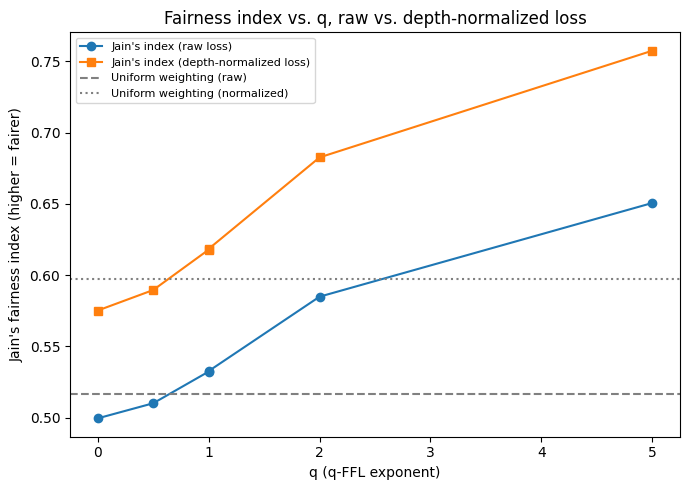

In [7]:
qffl_rows = summary_df[summary_df["q"].notna()].sort_values("q")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(qffl_rows["q"], qffl_rows["jain_raw"], marker="o", label="Jain's index (raw loss)")
ax.plot(qffl_rows["q"], qffl_rows["jain_norm"], marker="s", label="Jain's index (depth-normalized loss)")

if "Uniform weighting" in summary_df.index:
    ax.axhline(summary_df.loc["Uniform weighting", "jain_raw"], color="gray", linestyle="--",
               label="Uniform weighting (raw)")
    ax.axhline(summary_df.loc["Uniform weighting", "jain_norm"], color="gray", linestyle=":",
               label="Uniform weighting (normalized)")

ax.set_xlabel("q (q-FFL exponent)")
ax.set_ylabel("Jain's fairness index (higher = fairer)")
ax.set_title("Fairness index vs. q, raw vs. depth-normalized loss")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

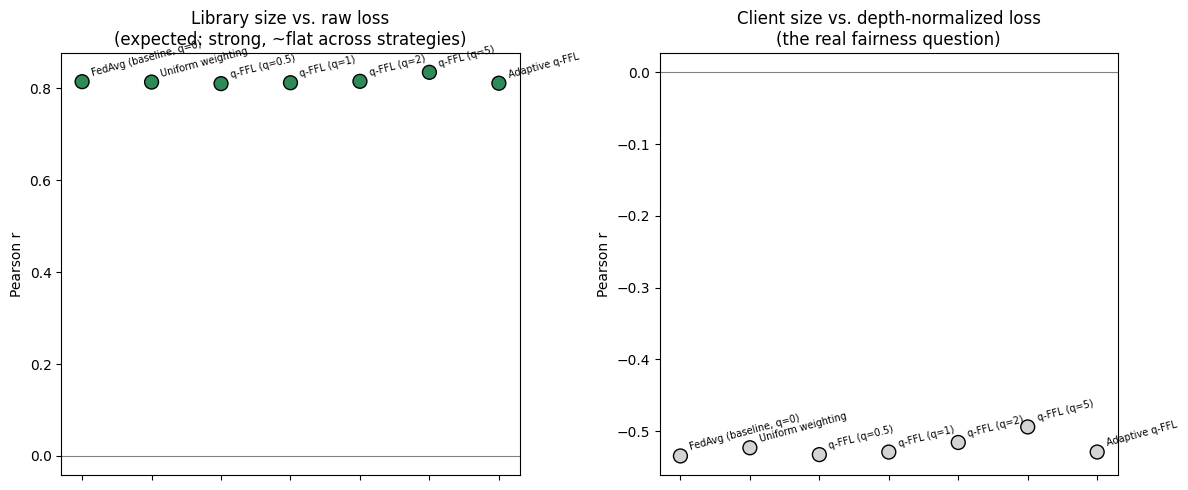

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_all = summary_df["q"].fillna(-1)  # put non-q strategies (uniform) at x=-1 for visibility
labels = summary_df.index.tolist()

for ax, rcol, pcol, title, ylabel in [
    (axes[0], "corr_libsize_vs_rawloss_r", "corr_libsize_vs_rawloss_p",
     "Library size vs. raw loss\n(expected: strong, ~flat across strategies)",
     "Pearson r"),
    (axes[1], "corr_clientsize_vs_normloss_r", "corr_clientsize_vs_normloss_p",
     "Client size vs. depth-normalized loss\n(the real fairness question)",
     "Pearson r"),
]:
    colors = ["seagreen" if p < 0.05 else "lightgray" for p in summary_df[pcol]]
    ax.scatter(range(len(labels)), summary_df[rcol], c=colors, s=100, edgecolor="black", zorder=3)
    for i, label in enumerate(labels):
        ax.annotate(label, (i, summary_df[rcol].iloc[i]), textcoords="offset points",
                    xytext=(6, 4), fontsize=7, rotation=15)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([])
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.tight_layout()
plt.show()

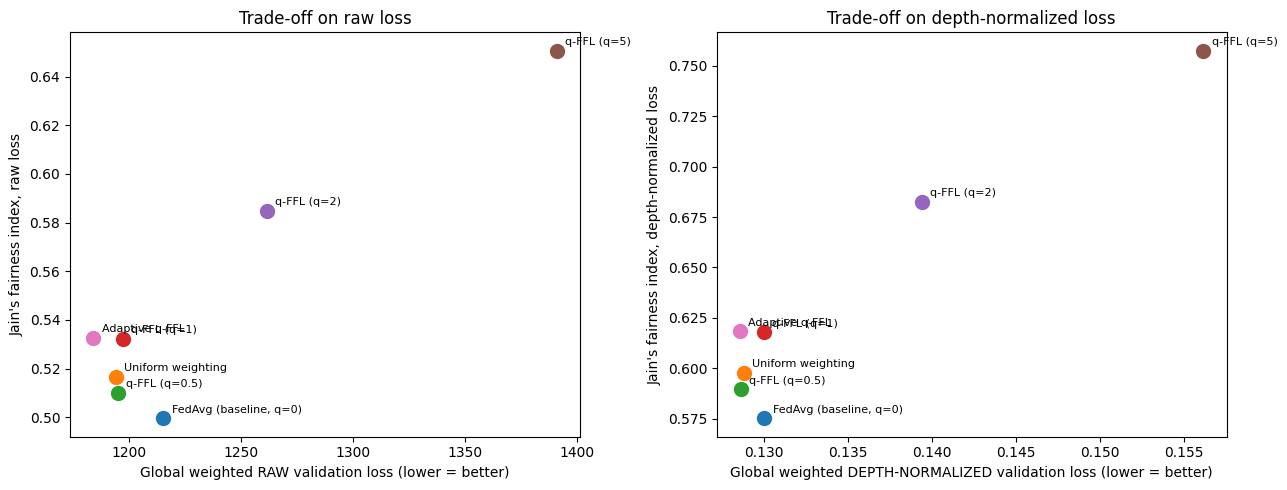

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, row in summary_df.iterrows():
    axes[0].scatter(row["global_weighted_raw_loss"], row["jain_raw"], s=100)
    axes[0].annotate(label, (row["global_weighted_raw_loss"], row["jain_raw"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[0].set_xlabel("Global weighted RAW validation loss (lower = better)")
axes[0].set_ylabel("Jain's fairness index, raw loss")
axes[0].set_title("Trade-off on raw loss")

for label, row in summary_df.iterrows():
    axes[1].scatter(row["global_weighted_norm_loss"], row["jain_norm"], s=100)
    axes[1].annotate(label, (row["global_weighted_norm_loss"], row["jain_norm"]),
                      textcoords="offset points", xytext=(6, 4), fontsize=8)
axes[1].set_xlabel("Global weighted DEPTH-NORMALIZED validation loss (lower = better)")
axes[1].set_ylabel("Jain's fairness index, depth-normalized loss")
axes[1].set_title("Trade-off on depth-normalized loss")

plt.tight_layout()
plt.show()

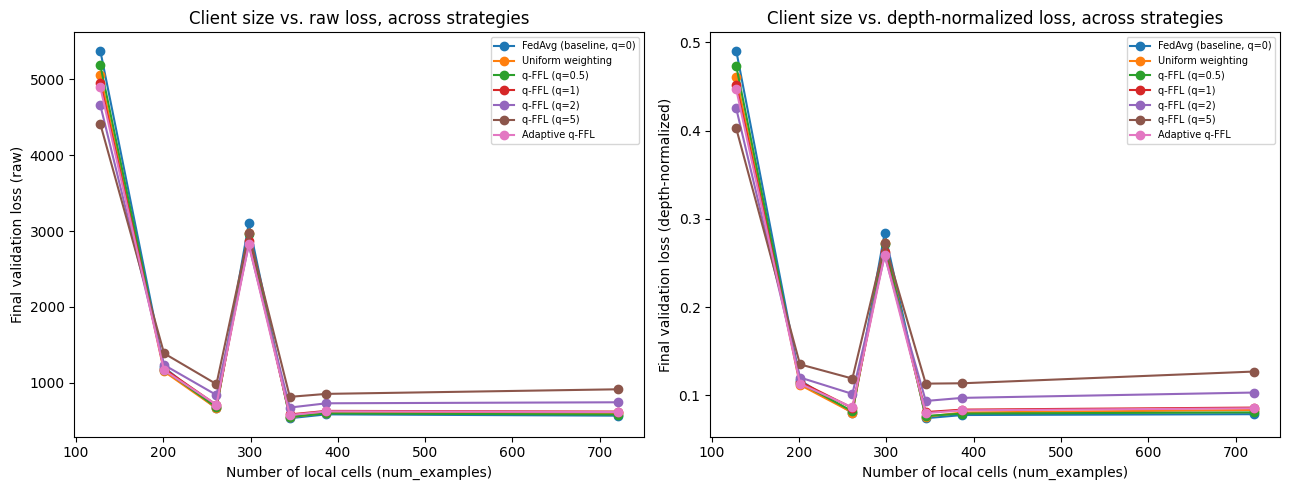

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, (df, _) in runs.items():
    final_round = df["round"].max()
    final_df = df[df["round"] == final_round].sort_values("num_examples")
    axes[0].plot(final_df["num_examples"], final_df["valid_loss"], marker="o", label=label)
    axes[1].plot(final_df["num_examples"], final_df["normalized_loss"], marker="o", label=label)

axes[0].set_xlabel("Number of local cells (num_examples)")
axes[0].set_ylabel("Final validation loss (raw)")
axes[0].set_title("Client size vs. raw loss, across strategies")
axes[0].legend(fontsize=7)

axes[1].set_xlabel("Number of local cells (num_examples)")
axes[1].set_ylabel("Final validation loss (depth-normalized)")
axes[1].set_title("Client size vs. depth-normalized loss, across strategies")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [11]:
N_CLIENTS = 7  
CLIENT_DIR_TEMPLATE = "../data_federated/data_client_{partition_id}"

rows = []
for pid in range(N_CLIENTS):
    client_folder = Path(CLIENT_DIR_TEMPLATE.format(partition_id=pid))

    train = anndata.read_h5ad(client_folder / "train.h5ad", backed="r")
    valid = anndata.read_h5ad(client_folder / "valid.h5ad", backed="r")

    techs_train = train.obs["tech"].value_counts().to_dict() if "tech" in train.obs else {}
    techs_valid = valid.obs["tech"].value_counts().to_dict() if "tech" in valid.obs else {}

    rows.append({
        "partition_id": pid,
        "n_train": train.n_obs,
        "n_valid": valid.n_obs,
        "n_total": train.n_obs + valid.n_obs,
        "tech_train": techs_train,
        "tech_valid": techs_valid,
    })

    train.file.close()
    valid.file.close()

df = pd.DataFrame(rows).sort_values("n_total")
pd.set_option("display.max_colwidth", None)
print(df.to_string(index=False))

 partition_id  n_train  n_valid  n_total          tech_train          tech_valid
            1      510      128      638 {'fluidigmc1': 510} {'fluidigmc1': 128}
            0      803      201     1004     {'celseq': 803}     {'celseq': 201}
            5     1042      261     1303   {'inDrop4': 1042}    {'inDrop4': 261}
            6     1194      298     1492   {'smarter': 1194}    {'smarter': 298}
            3     1379      345     1724   {'inDrop2': 1379}    {'inDrop2': 345}
            2     1550      387     1937   {'inDrop1': 1550}    {'inDrop1': 387}
            4     2884      721     3605   {'inDrop3': 2884}    {'inDrop3': 721}


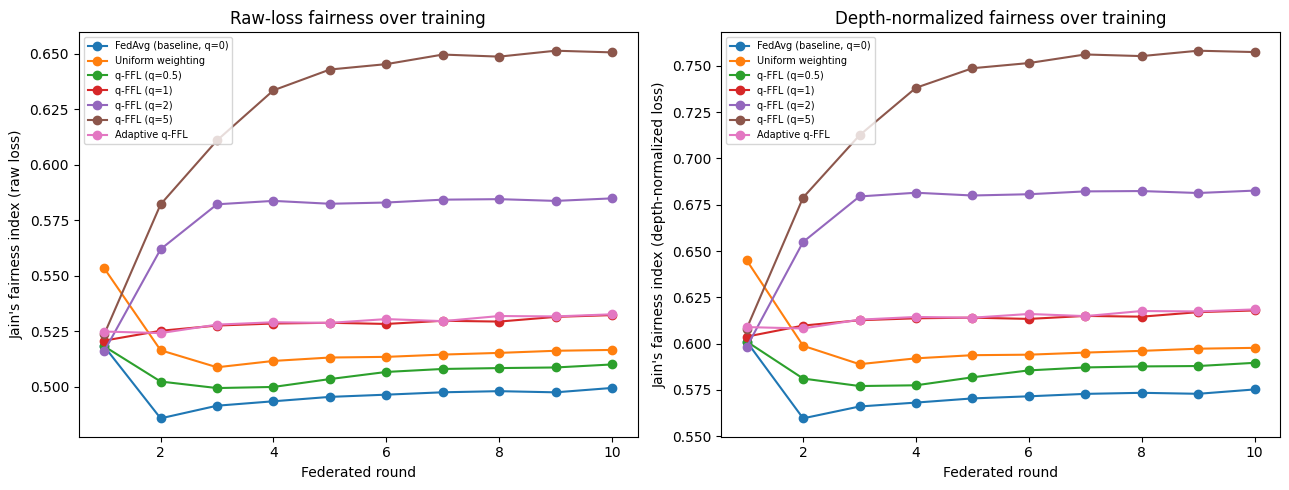

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, (df, metrics_df) in runs.items():
    axes[0].plot(metrics_df["round"], metrics_df["jain_index"], marker="o", label=label)
    norm_metrics = normalized_metrics_over_rounds(df)
    axes[1].plot(norm_metrics["round"], norm_metrics["jain_index_norm"], marker="o", label=label)

axes[0].set_xlabel("Federated round")
axes[0].set_ylabel("Jain's fairness index (raw loss)")
axes[0].set_title("Raw-loss fairness over training")
axes[0].legend(fontsize=7)

axes[1].set_xlabel("Federated round")
axes[1].set_ylabel("Jain's fairness index (depth-normalized loss)")
axes[1].set_title("Depth-normalized fairness over training")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()